In [1]:
# https://scores.readthedocs.io/en/stable/tutorials/Fractions_Skill_Score.html

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pathlib import Path
from datetime import datetime
import re
import pandas as pd
from scores.spatial import fss_2d

from dask.distributed import Client, wait
import os, sys
import psutil

sys.path.append('/home/548/cd3022/repos/Irradiance-comparisons/Irradiance-comparisons')
import logger
from read_datasets import read_dataset

LOG = logger.get_logger(__name__)

In [2]:
client = Client(
    n_workers=48,
    threads_per_worker=1
)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 48
Total threads: 48,Total memory: 188.56 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44101,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33869,Total threads: 1
Dashboard: /proxy/38727/status,Memory: 3.93 GiB
Nanny: tcp://127.0.0.1:40583,


In [3]:
# ds_ct = xr.open_zarr("/g/data/su28/himawari-ahi/cloud/ct/aus_regional_domain/S_NWC_CT_HIMA08_HIMA-N-NR.zarr/")

# lat=slice(-10, -44.5)
# lon=slice(112, 156.26)
# ds_ct = ds_ct.sel(
#     lat=lat,
#     lon=lon,
# )

In [4]:
path = Path('/g/data/rv74/satellite-products/arc/der/himawari-ahi/solar/p1s/latest/2020/01/01')
files = [f for f in path.glob('*.nc')]

ds_sol = xr.open_mfdataset(files)

In [5]:
# BARRA Cloud Types
BARRA = Path('/g/data/ob53/BARRA2/output/reanalysis/')
BARRA_R2 = BARRA / "AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1"
BARRA_R2_DIR = BARRA_R2 / "1hr"

def _preprocess(ds):
    return ds.sel(lat=slice(-44.5, -10), lon=slice(112, 156.26), time=slice('2016', '2024'))


files = sorted([f for f in BARRA_R2_DIR.glob('clt/latest/*1hr_20*.nc')])
bar = xr.open_mfdataset(files,
                    chunks='auto',
                    concat_dim='time',
                    combine='nested',
                    data_vars='minimal',
                    coords='minimal',
                    compat='override',
                    parallel=True,
                    preprocess=_preprocess
                    )

In [6]:
bar = bar.sel(time='2020-01-01')
# ds_sol = ds_sol.sel(time=bar.time)

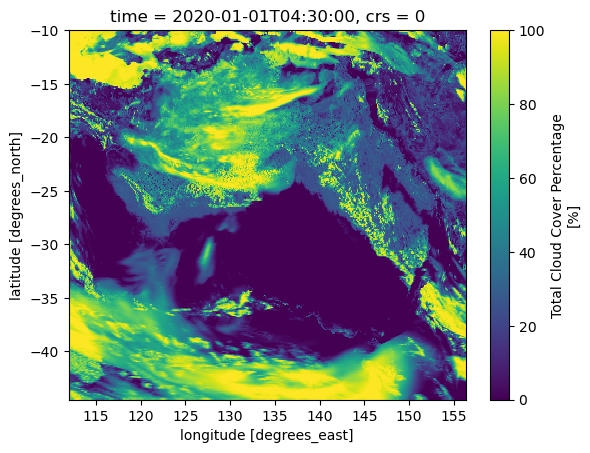

In [7]:
time = '2020-01-01T04:30:00.000000000'
bar.sel(time=time).clt.plot()

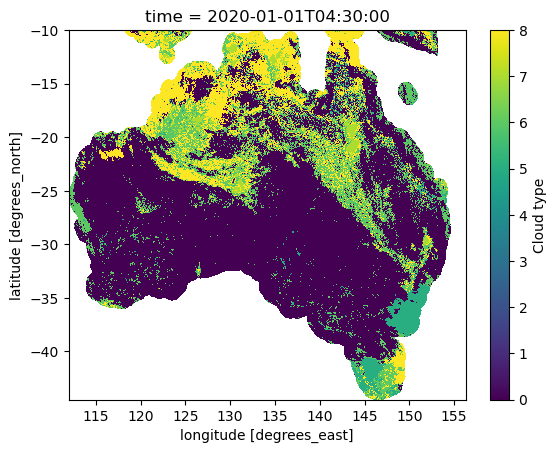

In [8]:
ds_sol.sel(
    time=time,
).cloud_type.plot()

In [9]:
# import matplotlib.pyplot as plt
# from matplotlib import colormaps
# import matplotlib.colors as mcolors
# from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
# import matplotlib.cm as cm
# import cartopy.crs as ccrs
# import cartopy.feature as cft
# import cmocean as cmo
# import matplotlib as mpl
# import matplotlib.ticker as mticker

# import re

# comment = '1:  Cloud-free land; 2:  Cloud-free sea; 3:  Snow over land;  4:  Sea ice; 5:  Very low clouds; 6:  Low clouds; 7:  Mid-level clouds;  8:  High opaque clouds; 9:  Very high opaque clouds;  10:  Fractional clouds; 11:  High semitransparent thin clouds;  12:  High semitransparent moderately thick clouds;  13:  High semitransparent thick clouds;  14:  High semitransparent above low or medium clouds;  15:  High semitransparent above snow/ice'

# # Use regex to extract values and labels
# matches = re.findall(r'(\d+):\s+([^;]+)', comment)
# category_dict = {int(num): desc.strip() for num, desc in matches}

# fig = plt.figure(figsize=(16, 8))

# ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=130))
# ax.coastlines(resolution="50m", color='white')

# # Define the values and corresponding colors from tab20
# values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  # Adjust based on your dataset
# # Set the min and max colors from tab20
# min_color = mpl.colormaps['tab20'](0 / 20)
# max_color = mpl.colormaps['tab20'](19 / 20)  # Last color of tab20

# # Generate intermediate colors by linearly spacing them within tab20
# num_classes = len(values)
# colors = [mpl.colormaps['tab20'](i / (num_classes - 1)) for i in range(num_classes)]

# # Ensure min/max colors are set explicitly
# colors[0] = min_color
# colors[-1] = max_color

# # Create discrete colormap
# cmap = mcolors.ListedColormap(colors)
# # Define boundaries for normalization (each value gets its own bin)
# boundaries = np.arange(min(values) - 0.5, max(values) + 1.5, 1)  # Adjusted for correct binning
# norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# img = ds_ct.sel(time=time).ct.plot(ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(), cmap=cmap, norm=norm, add_colorbar=False)

# # Add a discrete colorbar
# cbar = fig.colorbar(img, ax=ax, orientation="vertical", fraction=0.03, pad=0.02)
# cbar.set_label("Cloud Type (CT)", fontsize=12)
# cbar.set_ticks(values)  # Ensure ticks match category values
# cbar.set_ticklabels([f"{k}: {v}" for k, v in sorted(category_dict.items())[:14]])  # Custom labels

# # Add gridlines with labels
# gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=1.0)
# gl.top_labels = False  # Disable top labels
# gl.right_labels = False  # Disable right labels

# # Increase the number of ticks on the x-axis
# gl.xlocator = mticker.FixedLocator(np.arange(70, 190, 20))  # Adjust step size as needed

# Group Cloud Types for FSS

In [10]:
# # Assign cloud to himawari if any cloud type observed
# ds_ct['clt'] = xr.where(ds_ct.ct > 4, 1, 0)

In [ ]:
ds_sol['clt'] = xr.where(ds_sol.cloud_type > 0, 1, 0)
ds_sol = ds_sol.interp(
    latitude=bar.lat,
    longitude=bar.lon,
    method='linear'
)

In [ ]:
ds_sol.clt.sel(
    time=time,
    latitude=slice(-15, -20),
    longitude=slice(135, 140)
).plot()

In [ ]:
ds_sol.clt.sel(
    time=time,
    latitude=slice(-15, -20),
    longitude=slice(135, 140)
).plot()

# Apply FSS